In [2]:

# Import Required Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

# Set style for better visuals
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [5]:

# Load dataset from Colab
df = pd.read_csv('/content/ipldataset.csv', low_memory=False)

# View first 5 rows
df.head()

,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_balls,team_wicket,new_batter,power_surge_start,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,141607,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,1,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,141608,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,2,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,141609,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
3,141610,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,3,0,NaN,NaN,0,2,0,"('BB McCullum', 'SC Ganguly')",NaN,False
4,141611,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,...,4,0,NaN,NaN,0,3,0,"('BB McCullum', 'SC Ganguly')",NaN,False


In [6]:
# Basic Information
df.shape
df.columns
df.info()

# Check missing values
df.isnull().sum().sort_values(ascending=False).head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283678 entries, 0 to 283677
Data columns (total 65 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         283678 non-null  int64  
 1   match_id           283678 non-null  int64  
 2   date               283678 non-null  object 
 3   match_type         283678 non-null  object 
 4   event_name         283678 non-null  object 
 5   innings            283678 non-null  int64  
 6   batting_team       283678 non-null  object 
 7   bowling_team       283678 non-null  object 
 8   over               283678 non-null  int64  
 9   ball               283678 non-null  int64  
 10  ball_no            283678 non-null  float64
 11  batter             283678 non-null  object 
 12  bat_pos            283678 non-null  int64  
 13  runs_batter        283678 non-null  int64  
 14  balls_faced        283678 non-null  int64  
 15  bowler             283678 non-null  object 
 16  va

,0
power_surge_start,283678
team_reviewed,282771
review_batter,282771
review_decision,282771
umpire,282771
method,279788
superover_winner,279782
result_type,278954
fielders,273433
next_batter,270085


In [7]:
# Data Cleaning
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

# Convert date column
df['date'] = pd.to_datetime(df['date'])

# Fill missing values
df['wicket_kind'].fillna("No Wicket", inplace=True)
df['extra_type'].fillna("None", inplace=True)

/tmp/ipykernel_12153/1917812987.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['wicket_kind'].fillna("No Wicket", inplace=True)
/tmp/ipykernel_12153/1917812987.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

In [8]:
# Check dataset year range
print("Start Year:", df['year'].min())
print("End Year:", df['year'].max())

# Matches per year
df['year'].value_counts().sort_index()

Start Year: 2008
End Year: 2026


,count
year,
2008,13489
2009,13606
2010,14498
2011,17013
2012,17767
2013,18177
2014,14300
2015,13652
2016,14096


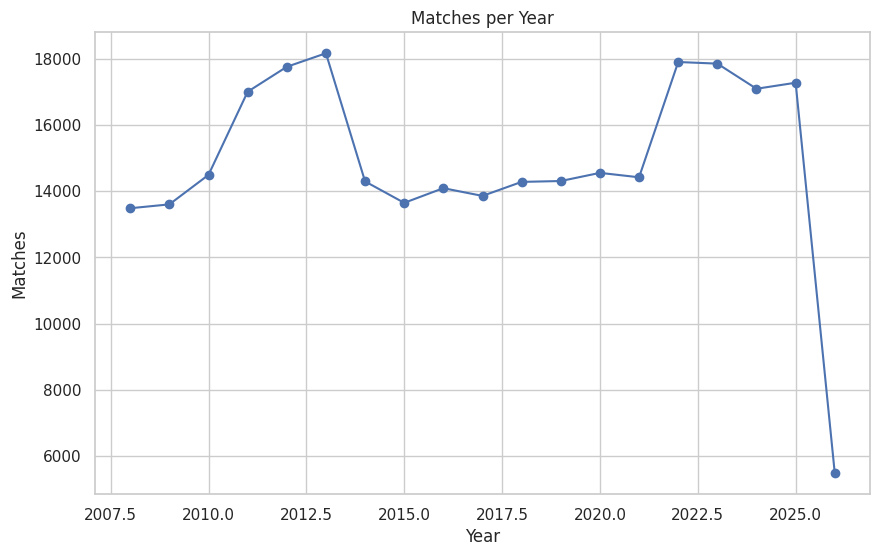

In [9]:
# Matches per year plot
year_counts = df['year'].value_counts().sort_index()

plt.plot(year_counts.index, year_counts.values, marker='o')
plt.xlabel("Year")
plt.ylabel("Matches")
plt.title("Matches per Year")
plt.show()

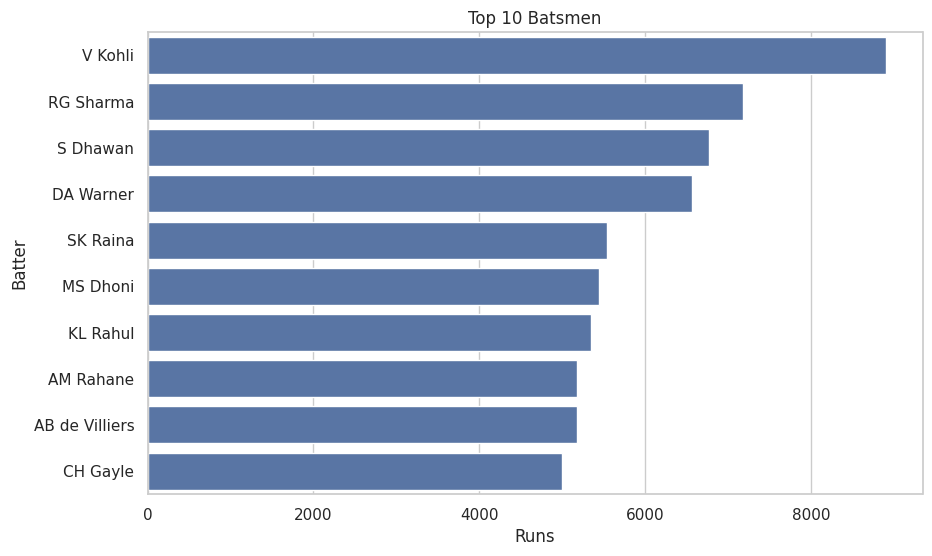

In [10]:
# Top batsmen by total runs
top_batsmen = df.groupby('batter')['runs_batter'].sum() \
    .sort_values(ascending=False).head(10)

sns.barplot(x=top_batsmen.values, y=top_batsmen.index)
plt.xlabel("Runs")
plt.ylabel("Batter")
plt.title("Top 10 Batsmen")
plt.show()

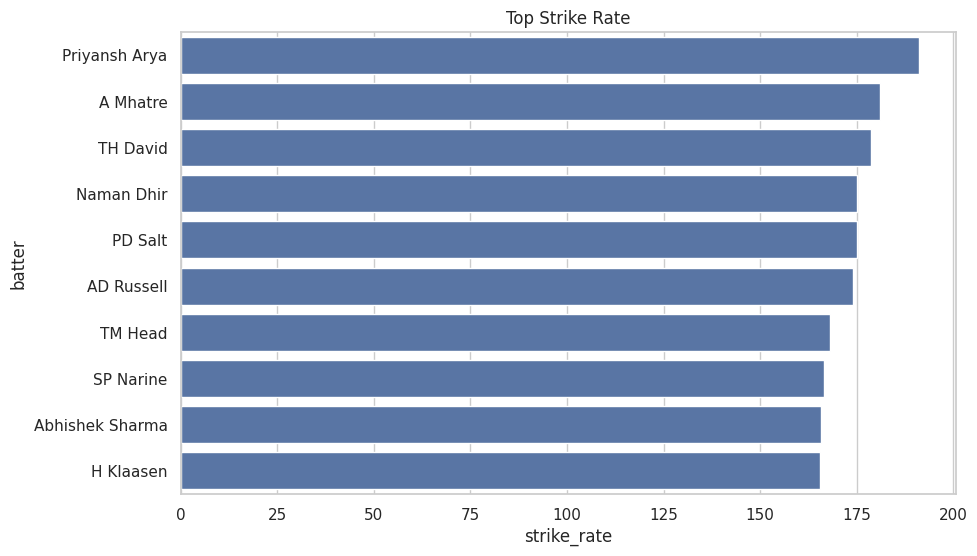

In [11]:
# Strike rate calculation
batsman_stats = df.groupby('batter').agg({
    'runs_batter': 'sum',
    'balls_faced': 'sum'
}).reset_index()

batsman_stats['strike_rate'] = (
    batsman_stats['runs_batter'] / batsman_stats['balls_faced']
) * 100

# Filter players with enough balls
top_sr = batsman_stats[batsman_stats['balls_faced'] > 200] \
    .sort_values(by='strike_rate', ascending=False).head(10)

sns.barplot(x=top_sr['strike_rate'], y=top_sr['batter'])
plt.title("Top Strike Rate")
plt.show()

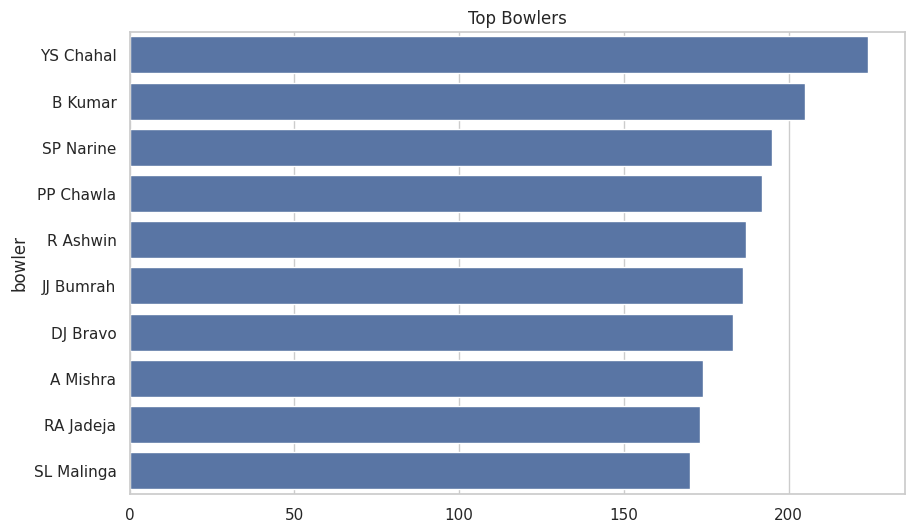

In [12]:
# Top bowlers by wickets
top_bowlers = df.groupby('bowler')['bowler_wicket'].sum() \
    .sort_values(ascending=False).head(10)

sns.barplot(x=top_bowlers.values, y=top_bowlers.index)
plt.title("Top Bowlers")
plt.show()

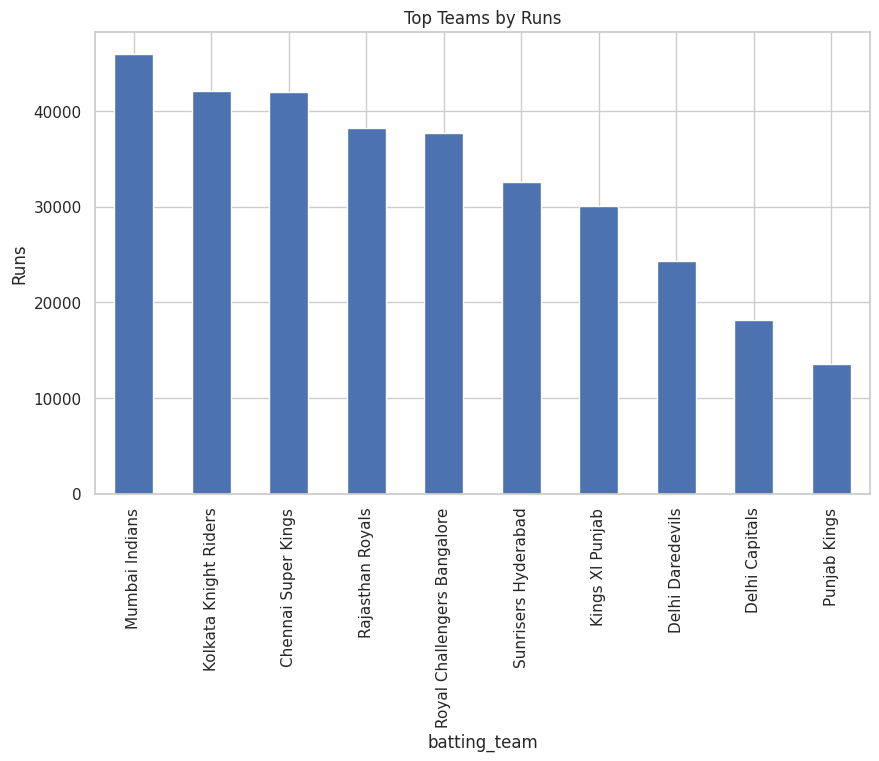

In [13]:
# Team performance by total runs
team_runs = df.groupby('batting_team')['runs_total'].sum() \
    .sort_values(ascending=False)

team_runs.head(10).plot(kind='bar')
plt.ylabel("Runs")
plt.title("Top Teams by Runs")
plt.show()

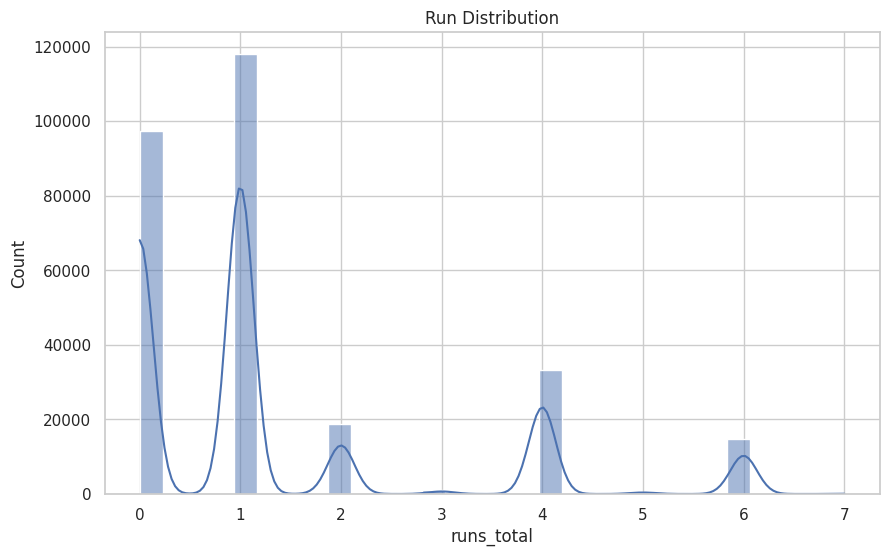

In [14]:
# Distribution of runs per ball
sns.histplot(df['runs_total'], bins=30, kde=True)
plt.title("Run Distribution")
plt.show()

In [15]:
# Interactive scatter plot
fig = px.scatter(
    batsman_stats,
    x='balls_faced',
    y='runs_batter',
    size='strike_rate',
    hover_name='batter'
)

fig.show()

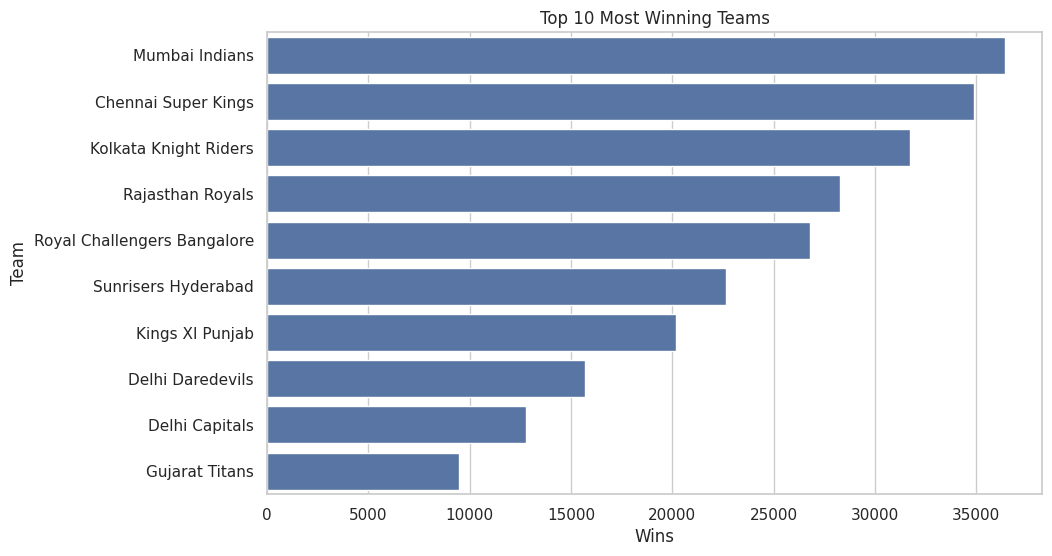

In [17]:
# Most winning teams
wins = df['match_won_by'].value_counts().head(10)

# Plot
sns.barplot(x=wins.values, y=wins.index)

plt.xlabel("Wins")
plt.ylabel("Team")
plt.title("Top 10 Most Winning Teams")

plt.show()

In [18]:
# Save cleaned dataset
df.to_csv('/content/cleaned_ipl_data.csv', index=False)

# Download file to your system
from google.colab import files
files.download('/content/cleaned_ipl_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
# Key insights

# Top batsman
top_batsman = df.groupby('batter')['runs_batter'].sum().idxmax()

# Top bowler
top_bowler = df.groupby('bowler')['bowler_wicket'].sum().idxmax()

# Top team (runs)
top_team = df.groupby('batting_team')['runs_total'].sum().idxmax()

# Most winning team
most_wins = df['match_won_by'].value_counts().idxmax()

# Best strike rate (min 200 balls)
best_sr = batsman_stats[batsman_stats['balls_faced'] > 200] \
    .sort_values(by='strike_rate', ascending=False).iloc[0]['batter']

print("Top Batsman:", top_batsman)
print("Top Bowler:", top_bowler)
print("Top Team (Runs):", top_team)
print("Most Winning Team:", most_wins)
print("Best Strike Rate:", best_sr)

Top Batsman: V Kohli
Top Bowler: YS Chahal
Top Team (Runs): Mumbai Indians
Most Winning Team: Mumbai Indians
Best Strike Rate: Priyansh Arya


In [20]:
# Save insights to text file

with open('/content/insights.txt', 'w') as f:
    f.write(f"Top Batsman: {top_batsman}\n")
    f.write(f"Top Bowler: {top_bowler}\n")
    f.write(f"Top Team (Runs): {top_team}\n")
    f.write(f"Most Winning Team: {most_wins}\n")
    f.write(f"Best Strike Rate: {best_sr}\n")

# Download insights file
from google.colab import files
files.download('/content/insights.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>